In [189]:
import pandas as pd
import scipy
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import random

In [190]:
mat_data = scipy.io.loadmat('../Data/Xtrain.mat')


In [191]:
mat_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Apr 29 11:11:31 2019',
 '__version__': '1.0',
 '__globals__': [],
 'Xtrain': array([[ 86],
        [141],
        [ 95],
        [ 41],
        [ 22],
        [ 21],
        [ 32],
        [ 72],
        [138],
        [111],
        [ 48],
        [ 23],
        [ 19],
        [ 27],
        [ 59],
        [129],
        [129],
        [ 58],
        [ 27],
        [ 19],
        [ 24],
        [ 46],
        [112],
        [144],
        [ 73],
        [ 30],
        [ 20],
        [ 19],
        [ 37],
        [ 92],
        [152],
        [ 93],
        [ 36],
        [ 20],
        [ 18],
        [ 29],
        [ 71],
        [146],
        [117],
        [ 46],
        [ 23],
        [ 18],
        [ 22],
        [ 52],
        [128],
        [142],
        [ 62],
        [ 26],
        [ 17],
        [ 19],
        [ 37],
        [100],
        [158],
        [ 86],
        [ 32],
        [ 17],
        [ 1

In [192]:
aa = scipy.io.loadmat('predictions.mat')

In [193]:
aa

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Mon May  4 17:54:00 2026',
 '__version__': '1.0',
 '__globals__': [],
 'pred_var': array([[ 37.219196],
        [ 30.331614],
        [ 32.15461 ],
        [ 46.49094 ],
        [ 90.95146 ],
        [118.14952 ],
        [ 74.20328 ],
        [ 36.660854],
        [ 29.558783],
        [ 30.919678],
        [ 43.7852  ],
        [ 89.174644],
        [121.52205 ],
        [ 79.370186],
        [ 37.08684 ],
        [ 29.014614],
        [ 29.783947],
        [ 41.088917],
        [ 85.78264 ],
        [121.59447 ],
        [ 87.071495],
        [ 39.270878],
        [ 28.923033],
        [ 28.741646],
        [ 37.577076],
        [ 78.750435],
        [120.1524  ],
        [ 96.41124 ],
        [ 43.322853],
        [ 29.701359],
        [ 27.708164],
        [ 34.69249 ],
        [ 68.82562 ],
        [115.921844],
        [108.26075 ],
        [ 49.630085],
        [ 30.171955],
        [ 26.579432],
        [ 31.433

In [194]:
print(mat_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


In [195]:
X = mat_data['Xtrain']
print(f"Feature shape: {X.shape}")

Feature shape: (1000, 1)


In [196]:
raw_data = X.astype(np.float32).flatten()

In [197]:
def create_data(data, window):
    rows = [data[i : i + window] for i in range(len(data) - window + 1)]
    columns = [f"x{i}" for i in range(window - 1)] + ["y"]

    return pd.DataFrame(rows, columns=columns)

In [198]:
split_idx = int(len(raw_data) * 0.8)
train_raw = np.array(raw_data[:split_idx]).reshape(-1, 1)
test_raw = np.array(raw_data[split_idx:]).reshape(-1, 1)

# 2. Fit the scaler ONLY on training data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw).flatten()

test_scaled = scaler.transform(test_raw).flatten()

In [199]:
class LaserDataset(Dataset):
    def __init__(self, df):
        # Separate features (X) and target (y)
        self.X = torch.tensor(df.drop('y', axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df['y'].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [200]:
class LaserPredictor(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(LaserPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 64 outputs
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 32 outputs
            
            nn.Linear(32, 1) # Never put dropout on the final output layer
        )

    def forward(self, x):
        return self.network(x)

In [201]:
def recursive_data_generation(x, model, k, num_samples) -> np.ndarray:
    """
    x: window
    model: model
    k: window size
    num_samples: number of predictions
    """
    # Evaluation Mode
    model.eval()

    # Initialize predicted samples array
    predicted_samples = np.zeros(num_samples, dtype=np.float32)

    # Make sure x is torch.tensor and not np.ndarray

    x = torch.tensor(x, dtype=torch.float32)

    # Make sure len(x) == k
    if len(x) > k:
        x = x[-k:].clone()
    elif len(x) < k:
        print(f"Window size of x must be at least {k} samples long")
        return np.empty((0, num_samples), dtype=np.float32)


    with torch.no_grad():
        for i in range(num_samples):
            # Predict next sample
            y = model(x)
            # Concatenate last-k window
            x = torch.cat([x[1:], y])
            # Add to prediction samples array
            predicted_samples[i] = y.item()

    return predicted_samples

In [ ]:
# Configuration
window_sizes = [i for i in range(3, 151)] # Started at 2 because window < 2 has no features
shuffle_options = [True, False]
# seeds = [42, 123, 999, 7, 2024, 222, 153, 23, 1111, 1263] # 10 different seeds
seeds = [random.randint(0, 2000) for _ in range(10)]
print(seeds)
epochs = 100 # Reduced slightly for the search; you can set back to 100
results = []

def set_seed(seed):
    """Utility to ensure reproducibility for each trial"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
shuffle_flag = True
for w in window_sizes:
        
        # Store val losses for the 5 seeds to average them later
        seed_val_losses = []
        seed_train_losses = []
        
        for seed in seeds:
            set_seed(seed) # Reset math state for this specific trial
            # print(f"seed value: {seed}")
            
            # 1. Re-generate data
            df_train = create_data(train_scaled, window=w)
            df_test = create_data(test_scaled, window=w)
            
            train_loader = DataLoader(LaserDataset(df_train), batch_size=32, shuffle=shuffle_flag)
            test_loader = DataLoader(LaserDataset(df_test), batch_size=32, shuffle=False)
            
            # 2. Initialize Model
            model = LaserPredictor(input_size=w - 1)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            criterion = torch.nn.MSELoss()
            
            # 3. Training Loop
            for epoch in range(epochs):
                model.train()
                total_train_loss = 0
                for batch_X, batch_y in train_loader:
                    optimizer.zero_grad()
                    loss = criterion(model(batch_X), batch_y)
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.item()
                
                # We calculate validation at the END of the training for this seed
                if epoch == epochs - 1:
                    window = list(train_scaled[-(w-1):])
                    preds = recursive_data_generation(x=window,model=model,k=w-1,num_samples=len(test_scaled))
                    recursive_val_mse = mean_squared_error(test_scaled, preds)
                    
                    seed_val_losses.append(recursive_val_mse)
                    seed_train_losses.append(total_train_loss / len(train_loader))

        # 4. Calculate averages across the 5 seeds
        avg_val_loss = np.mean(seed_val_losses)
        avg_train_loss = np.mean(seed_train_losses)
        std_val_loss = np.std(seed_val_losses) # Also useful to see how "stable" the window is

        results.append({
            'window_size': w,
            'shuffled': shuffle_flag,
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss,
            'val_std_dev': std_val_loss
        })

# 5. Final Results
results_df = pd.DataFrame(results)
print(f"\nFinal Experiment Results (Averaged over {len(seeds)} seeds):")
print(results_df.sort_values('avg_val_loss').head(10)) # Show top 10 configurations

[1634, 1463, 901, 542, 1929]

Final Experiment Results (Averaged over 5 seeds):
    window_size  shuffled  avg_train_loss  avg_val_loss  val_std_dev
13           16      True        0.001707      0.026607     0.012703
30           33      True        0.002001      0.026691     0.009357
21           24      True        0.001744      0.027525     0.011033
28           31      True        0.002119      0.028421     0.009975
1             4      True        0.002554      0.029035     0.001943
11           14      True        0.001559      0.029227     0.006829
24           27      True        0.001889      0.029602     0.005467
2             5      True        0.002361      0.030416     0.003814
32           35      True        0.001988      0.030587     0.002801
8            11      True        0.001819      0.030777     0.002288


27 7 35 36 21 5 40 50 18 16 

16 24 33 39 5 22 10 45 30 25 --- [1125, 862, 310, 477, 1127]

9 24 17 20 47 19 32 5 30 21 --- [1019, 319, 523, 1964, 195]

42 22 7 35 5 46 39 29 28 32 --- [1219, 810, 86, 1325, 408]

In [203]:
results_df.sort_values('avg_val_loss')

,window_size,shuffled,avg_train_loss,avg_val_loss,val_std_dev
13,16,True,0.001707,0.026607,0.012703
30,33,True,0.002001,0.026691,0.009357
21,24,True,0.001744,0.027525,0.011033
28,31,True,0.002119,0.028421,0.009975
1,4,True,0.002554,0.029035,0.001943
11,14,True,0.001559,0.029227,0.006829
24,27,True,0.001889,0.029602,0.005467
2,5,True,0.002361,0.030416,0.003814
32,35,True,0.001988,0.030587,0.002801
8,11,True,0.001819,0.030777,0.002288


In [224]:
BEST_WINDOW = results_df.sort_values('avg_val_loss').head(1)["window_size"].values[0]
# BEST_WINDOW = int(BEST_WINDOW.mean())
BEST_WINDOW = 30

In [225]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, path='best_checkpoint.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [226]:
def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        # Good for ReLU: variance is 2/n
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [227]:
# 1. Final Configuration
SHUFFLE_TRAIN = True
EPOCHS = 500 
LEARNING_RATE = 0.001
PATIENCE = 100 # How many epochs to wait before stopping

# 2. Data Preparation
df_train = create_data(train_scaled, window=BEST_WINDOW)
df_test = create_data(test_scaled, window=BEST_WINDOW)

train_loader = DataLoader(LaserDataset(df_train), batch_size=64, shuffle=SHUFFLE_TRAIN)
test_loader = DataLoader(LaserDataset(df_test), batch_size=64, shuffle=False)

# 3. Model Initialization
model = LaserPredictor(input_size=BEST_WINDOW - 1)
# model.apply(init_weights_kaiming)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.MSELoss()

# Initialize Early Stopping
early_stopper = EarlyStopping(patience=PATIENCE, path='laser_predictor_feedforward.pth')

# 4. Training Loop
print(f"Starting Final Training with Early Stopping...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    # --- VALIDATION PHASE (Required for Early Stopping) ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        window = list(train_scaled[-(BEST_WINDOW-1):])
        preds = []
        for step in range(200):                  # 200 steps recursive
            x = torch.tensor(window).view(1, -1)
            p = model(x).item()
            preds.append(p)
            window.pop(0)
            window.append(p)
            # print(f"p: {p}---truth: {test_scaled[step]}")
        recursive_val_mse = mean_squared_error(test_scaled, preds)
            
    avg_train = total_train_loss / len(train_loader)
    avg_val = recursive_val_mse
    
    # --- EARLY STOPPING CHECK ---
    early_stopper(avg_val, model)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

    if early_stopper.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {early_stopper.best_loss:.6f}")
        break

# 5. Finalize
# Load the best weights (the ones saved right before the model started overfitting)
model.load_state_dict(torch.load('laser_predictor_feedforward.pth'))
joblib.dump(scaler, 'laser_scaler_feedforward.pkl')
print("Best model weights loaded and scaler saved.")

Starting Final Training with Early Stopping...
Epoch [10/500] | Train Loss: 0.015015 | Val Loss: 0.033166
Epoch [20/500] | Train Loss: 0.009625 | Val Loss: 0.017947
Epoch [30/500] | Train Loss: 0.008872 | Val Loss: 0.027155
Epoch [40/500] | Train Loss: 0.005811 | Val Loss: 0.019347
Epoch [50/500] | Train Loss: 0.005506 | Val Loss: 0.002401
Epoch [60/500] | Train Loss: 0.004972 | Val Loss: 0.033156
Epoch [70/500] | Train Loss: 0.004863 | Val Loss: 0.077014
Epoch [80/500] | Train Loss: 0.004910 | Val Loss: 0.028580
Epoch [90/500] | Train Loss: 0.003837 | Val Loss: 0.049511
Epoch [100/500] | Train Loss: 0.002718 | Val Loss: 0.026524
Epoch [110/500] | Train Loss: 0.003037 | Val Loss: 0.065765
Epoch [120/500] | Train Loss: 0.002634 | Val Loss: 0.018439
Epoch [130/500] | Train Loss: 0.002515 | Val Loss: 0.014283
Epoch [140/500] | Train Loss: 0.003131 | Val Loss: 0.015385
Epoch [150/500] | Train Loss: 0.002536 | Val Loss: 0.015466
Early stopping triggered at epoch 150. Best Val Loss: 0.002401

In [228]:
class LaserPredictor(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(LaserPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 64 outputs
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly zeroes 20% of the 32 outputs
            nn.Linear(32, 1) # Never put dropout on the final output layer
        )

    def forward(self, x):
        return self.network(x)

def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        # Good for ReLU: variance is 2/n
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
# 2. Initialize and Load
# Use the same BEST_WINDOW (15) from your training
model = LaserPredictor(input_size=BEST_WINDOW -1) 
model.load_state_dict(torch.load('laser_predictor_feedforward.pth'))
# model.eval()  # CRITICAL: Sets the model to inference mode

# 3. Load the Scaler
scaler = joblib.load('laser_scaler_feedforward.pkl')

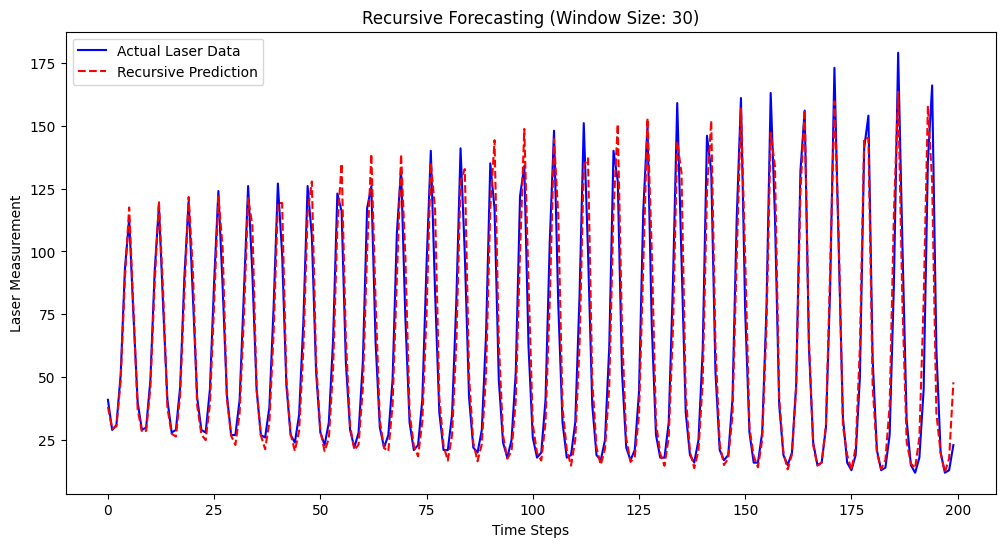

In [229]:
# Assuming window size is 15, so input_size is 14
k_minus_1 = BEST_WINDOW -1

# 1. Take the last 14 points from the SCALED training data
# This is our initial "sliding window"
current_window = list(train_scaled[-k_minus_1:])

# List to store our recursive predictions
recursive_predictions = recursive_data_generation(x=current_window, model=model, k =BEST_WINDOW -1, num_samples=len(test_scaled)).reshape(-1, 1)
final_forecast = scaler.inverse_transform(recursive_predictions)
scipy.io.savemat('predictions.mat', {'pred_var': final_forecast})
actual_test_values = scaler.inverse_transform(test_scaled.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(actual_test_values, label='Actual Laser Data', color='blue')
plt.plot(final_forecast, label='Recursive Prediction', color='red', linestyle='--')
plt.title(f"Recursive Forecasting (Window Size: {k_minus_1+1})")
plt.xlabel("Time Steps")
plt.ylabel("Laser Measurement")
plt.legend()
plt.show()

In [230]:
mae = mean_absolute_error(actual_test_values, final_forecast)
mse = mean_squared_error(actual_test_values, final_forecast)
rmse = np.sqrt(mse) # Root Mean Squared Error is also very helpful

print(f"--- Recursive Forecast Metrics (Original Units) ---")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

--- Recursive Forecast Metrics (Original Units) ---
MAE : 8.7215
MSE : 153.6573
RMSE: 12.3959


In [219]:
for p,r in zip(final_forecast, actual_test_values):
    print(f"prediction: {p}, truth: {r}, difference: {abs(p - r)}")

prediction: [36.382782], truth: [41.], difference: [4.617218]
prediction: [26.21568], truth: [29.], difference: [2.7843208]
prediction: [27.568901], truth: [31.], difference: [3.431099]
prediction: [46.71513], truth: [51.], difference: [4.28487]
prediction: [90.10177], truth: [93.], difference: [2.8982315]
prediction: [115.363144], truth: [113.], difference: [2.363144]
prediction: [74.32496], truth: [75.], difference: [0.6750412]
prediction: [35.751263], truth: [40.], difference: [4.2487373]
prediction: [25.859507], truth: [29.], difference: [3.1404934]
prediction: [25.39839], truth: [30.], difference: [4.60161]
prediction: [43.223385], truth: [49.], difference: [5.776615]
prediction: [87.869095], truth: [92.], difference: [4.130905]
prediction: [118.773094], truth: [118.], difference: [0.7730942]
prediction: [80.33716], truth: [78.], difference: [2.3371582]
prediction: [36.613586], truth: [41.], difference: [4.3864136]
prediction: [24.721733], truth: [28.], difference: [3.278267]
pred